<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Coulomb_matrix_representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Load modules and data

! pip install dscribe
import numpy as np
import math, random
import matplotlib.pyplot as plt
import pandas as pd
import json
import seaborn as sns
from scipy.sparse import load_npz
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from dscribe.descriptors import CoulombMatrix 
from ase import *
from ase.build import molecule
from ase.io import read, write
import io


     |████████████████████████████████| 143 kB 5.2 MB/s 
  Using cached pybind11-2.7.1-py2.py3-none-any.whl (200 kB)
     |████████████████████████████████| 2.2 MB 38.0 MB/s 
     |████████████████████████████████| 76 kB 3.5 MB/s 
  Created wheel for dscribe: filename=dscribe-1.1.0-cp37-cp37m-linux_x86_64.whl size=4339740 sha256=e35c8b71272b9ace0c430973c143e741eea3d9411c297910f543574c5787895a
  Stored in directory: /root/.cache/pip/wheels/05/f8/a6/c5328c447d56d1efed920c372cbd0086ac1e01de1b5adaa9db
Successfully built dscribe


In [ ]:
!cp '/content/drive/MyDrive/ColabNotebooks/Data/helpers.py' .

from helpers import get_level  # needs to go here as wont have been downloaded earlier in

def xyz_to_atoms(xyz):
    f = io.StringIO()
    f.write(xyz)
    f.seek(0)  # had to add this in otherwise wont return to start of file once read in
    atoms = read(f, format="xyz")
    return atoms

print('Loading data...')
df = pd.read_json('/content/drive/MyDrive/ColabNotebooks/Data/df_5k.json', orient='split')

print('Generating `ase.Atoms` objects...')
df['atoms'] = df['xyz_pbe_relaxed'].apply(xyz_to_atoms)

print('Extracting HOMO, LUMO, BANDGAP from data...')
df['HOMO'] = df.apply(lambda row: get_level(row, level_type='HOMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['LUMO'] = df.apply(lambda row: get_level(row, level_type='LUMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['BG'] = df['LUMO'] - df['HOMO']
print('~ 2300 molecules do not have LUMO energy levels for this or any other `GOWO` level of theory.')

print('Splitting data set...')
train, test = train_test_split(df, test_size=0.2, random_state=20210817)
train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

print('Data Processing Complete')
print('#', '-'*119)

Loading data...
Generating `ase.Atoms` objects...
Extracting HOMO, LUMO, BANDGAP from data...
err FOVWES
err FOWGIH
err FOYJUZ
err FUNBUL
err FUPZAR
err FUXFAG
err GANSAQ
err GAQCEI
err NUFRUB
err GEPHEO
err GERGOB
err GETBUD
err GEVDAN
err GEYQAC
err GIDQAN
err GIMPUO
err GISBOA
err NUNJAH
err NUNJEL
err NUNKEM
err GODBUW
err NUQCIM
err WEBWUV
err GUCLIA
err GUMBEV
err HACGAT
err HADSEM
err HANBEF
err HANNEP
err LUXPAW
err HAVSIH
err HAWTEF
err HAXWAG
err HAZFNO
err HEHQIW
err HEJGOS
err HELCEG
err HEMLIU
err HEQMOG
err HERKEV
err HESKOF01
err HEVNAX
err HEVNIF
err HEWJIE
err OBOYOV
err HIFYAY
err HIJCEI
err HINREB
err HINTAZ
err WUJHOY
err HIVCOF
err HIXLOP
err WULZIM
err HMNCXC01
err HMSPYR
err HMTCSP10
err HOFJOB
err HOHGER
err HOHLAR
err HOJVUX
err HOKZEN
err HOQHUQ
err HORNUY
err OCAYUN
err HUHJUQ
err HUXKOB
err IFEFII
err IFOQIE
err LUZKEX
err IJEDAC
err IJENIU
err IJIWIH
err ILIGAM
err ILOCAN
err LOFBUD
err XILQUE
err IMINEY
err IMSTXP10
err IQAHUD
err XINWUN
err IROQOV
err IRU

In [ ]:
col_names = list(df.columns)
print(col_names)
df.head(3)
print(df.shape[0])

['refcode_csd', 'canonical_smiles', 'inchi', 'number_of_atoms', 'xyz_pbe_relaxed', 'energies_occ_pbe', 'energies_occ_pbe0_vac_tier2', 'energies_occ_pbe0_water', 'energies_occ_pbe0_vac_tzvp', 'energies_occ_pbe0_vac_qzvp', 'energies_occ_gw_tzvp', 'energies_occ_gw_qzvp', 'cbs_occ_gw', 'energies_unocc_pbe', 'energies_unocc_pbe0_vac_tier2', 'energies_unocc_pbe0_water', 'energies_unocc_pbe0_vac_tzvp', 'energies_unocc_pbe0_vac_qzvp', 'energies_unocc_gw_tzvp', 'energies_unocc_gw_qzvp', 'cbs_unocc_gw', 'total_energy_pbe', 'total_energy_pbe0_vac_tier2', 'total_energy_pbe0_water', 'total_energy_pbe0_vac_tzvp', 'total_energy_pbe0_vac_qzvp', 'hirshfeld_pbe', 'hirshfeld_pbe0_vac_tier2', 'hirshfeld_pbe0_water', 'atoms', 'HOMO', 'LUMO', 'BG']
5239


In [ ]:

#Lets look at a random molecule represented with a Coulomb matrix 
y = df['xyz_pbe_relaxed'].shape[0]
# print(df['xyz_pbe_relaxed'])
print(y)

rand_mol = random.randint(0, y)
print(df['xyz_pbe_relaxed'].iloc[rand_mol])
mol_of_choice = df['xyz_pbe_relaxed'].iloc[rand_mol]


5239
43

C       4.62982221      39.44358833      29.06656310 
C       5.01310548      37.56647091      27.38950942 
C       5.93326784      36.42297283      26.94129143 
C       6.27628449      35.52078417      28.12860405 
C       6.84956733      36.41920401      29.24944009 
C       7.47427431      34.57808786      27.92555311 
C       5.03979026      34.72851872      28.59196038 
C       5.56324360      38.33055778      28.61092321 
H       4.25353108      40.17725020      27.06776583 
H       4.88188307      38.26855193      26.55604389 
H       4.01155251      37.18753143      27.63907914 
H       6.86806371      36.84551996      26.53397359 
H       5.46408959      35.84892881      26.12896167 
H       4.28925648      35.39976247      29.02338986 
H       5.28600024      33.97696840      29.35214304 
H       4.59791818      34.19335700      27.74259722 
H       7.90522801      32.92537649      26.96475545 
H       8.25665219      35.13305809      27.37450041 
H       6.52325683 

In [ ]:
cm_desc = CoulombMatrix(n_atoms_max=43, permutation='none', flatten=False)
mol = df['atoms'].iloc[rand_mol]

print("answer:", isinstance(mol, Atoms))

matrix = cm_desc.create(mol)
print(matrix.shape)

# shape = (34, 34)
# matrix = matrix.reshape(shape)
# print("new shape", matrix.shape)
# df['atoms'].head(5)

answer: True
(43, 43)


<Figure size 432x288 with 0 Axes>

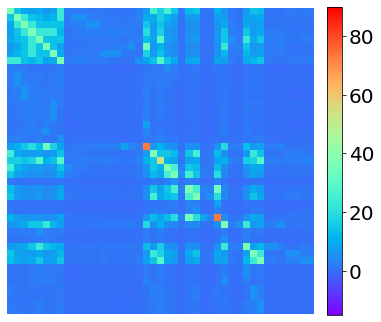

In [ ]:
#Lets have a look at our random molecule and visualise the CM
plt.figure()
plt.figure(figsize = (6,6))
plt.imshow(matrix, origin="upper", cmap='rainbow', vmin=-15, vmax=90, interpolation='nearest')
plt.colorbar(fraction=0.046, pad=0.04).ax.tick_params(labelsize=20)
plt.axis('off')
plt.show()

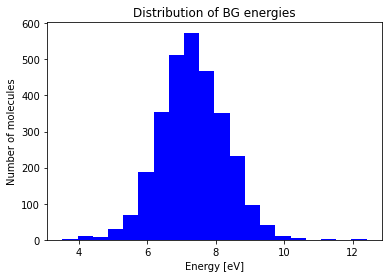

Mean value of HOMO energies in OE62 dataset: 7.33 eV


In [ ]:
plt.hist(df['BG'].values, bins=20, density=False, facecolor='blue')
plt.xlabel("Energy [eV]")
plt.ylabel("Number of molecules")
plt.title("Distribution of BG energies")
plt.show()

## mean value of distribution
print("Mean value of HOMO energies in OE62 dataset: %0.2f eV" %np.mean(df['BG'].dropna().values))

In [ ]:
 train, test = train_test_split(df, test_size=0.2, random_state=20210817)
train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

In [ ]:
# train['CM_rep'].values

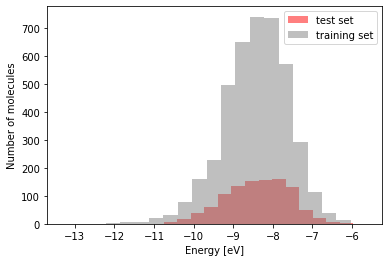

Mean value of HOMO energies in training set: -8.43 eV
Mean value of HOMO energies in test set: -8.39 eV


In [ ]:
#Lets visualise the data for each split to see if it resembles each other


plt.hist(test['HOMO'].values, bins=20, density=False, alpha=0.5, facecolor='red', label='test set')
plt.hist(train['HOMO'].values, bins=20, density=False, alpha=0.5, facecolor='gray', label='training set')
plt.xlabel("Energy [eV]")
plt.ylabel("Number of molecules")
plt.legend()
plt.show()

## mean value of distributions
print("Mean value of HOMO energies in training set: %0.2f eV" %np.mean(train['HOMO'].values))
print("Mean value of HOMO energies in test set: %0.2f eV" %np.mean(test['HOMO'].values))

Okay, so we need to generate a new col in the datframe with the CM for each and every molecule in the set
These will be the features and the labels are "train['BG'].dropna().values" 
We can then map the CM matrix to the BG gap

In [ ]:
cm_desc = CoulombMatrix(n_atoms_max=120, permutation='none', flatten=False, sparse=True)
# many_matrix = cm_desc.create(df['atoms'])

#Calum's victory 
df['CM_rep'] = df['atoms'].apply(cm_desc.create)
df.head(5)

,refcode_csd,canonical_smiles,inchi,number_of_atoms,xyz_pbe_relaxed,energies_occ_pbe,energies_occ_pbe0_vac_tier2,energies_occ_pbe0_water,energies_occ_pbe0_vac_tzvp,energies_occ_pbe0_vac_qzvp,energies_occ_gw_tzvp,energies_occ_gw_qzvp,cbs_occ_gw,energies_unocc_pbe,energies_unocc_pbe0_vac_tier2,energies_unocc_pbe0_water,energies_unocc_pbe0_vac_tzvp,energies_unocc_pbe0_vac_qzvp,energies_unocc_gw_tzvp,energies_unocc_gw_qzvp,cbs_unocc_gw,total_energy_pbe,total_energy_pbe0_vac_tier2,total_energy_pbe0_water,total_energy_pbe0_vac_tzvp,total_energy_pbe0_vac_qzvp,hirshfeld_pbe,hirshfeld_pbe0_vac_tier2,hirshfeld_pbe0_water,atoms,HOMO,LUMO,BG,CM_rep
10,FOVWES,COC(=O)[C@H](n1c(=S)sc(c1CC)C)C\t\n,InChI=1S/C10H15NO2S2/c1-5-8-7(3)15-10(14)11(8)...,30,30\n\nS 36.75934695 47.20389183 ...,"[-2412.24039, -2409.98986, -512.34265, -510.73...","[-2438.90946, -2436.50894, -524.75994, -523.16...","[-2439.12701, -2436.92988, -525.03583, -523.66...","[-2440.78485, -2438.41749, -524.75752, -523.11...","[-2439.03194, -2436.67645, -524.81876, -523.19...","[-29.1271, -24.9308, -24.2622, -23.3517, -22.6...","[-29.2628, -25.0892, -24.3714, -23.5214, -22.8...","[-29.36351, -25.20675, -24.45244, -23.64734, -...","[-1.79638, -1.16331, -0.8942200000000001, -0.7...","[-1.00989, -0.28629000000000004, -0.0223]","[-1.3107600000000001, -0.37236]","[-0.94898, -0.04764]","[-1.01171, -0.17985]",0.5708,0.2503,0.01245,-37957.125810,-37959.436725,-37959.781206,-37955.151866,-37958.392015,"[0.10253628000000001, 0.00547996, -0.012183910...","[0.09987054000000001, 0.02339617, -0.02340592,...","[0.10696537, 0.01796455, -0.01695311, 0.038783...","(Atom('S', [36.75934695, 47.20389183, 45.77859...",-7.52433,NaN,NaN,"((388.0234410266618, 54.94149853471995, 44.156..."
13,FOWGIH,O=P1Oc2ccccc2N(c2c(O1)cccc2)c1ccccc1O\t\n,InChI=1S/C18H14NO4P/c20-16-10-4-1-7-13(16)19-1...,38,38\n\nH 12.71064531 19.89742093 ...,"[-2091.34232, -512.89603, -512.82777, -511.071...","[-2116.2313, -525.35737, -525.2753, -523.39362...","[-2116.36062, -525.43865, -525.32768, -524.020...","[-2117.92912, -525.37336, -525.29157, -523.373...","[-2116.40386, -525.41418, -525.33251, -523.431...","[-29.1772, -28.1356, -25.4081, -25.0932, -24.3...","[-29.3487, -28.3072, -25.5324, -25.2152, -24.5...","[-29.49661, -28.4552, -25.63961, -25.32042, -2...","[-1.95194, -1.7190400000000001, -1.4932, -1.40...","[-1.0777700000000001, -0.8311200000000001, -0....","[-1.02904, -0.81579, -0.7339100000000001, -0.5...","[-1.0339, -0.7883600000000001, -0.568000000000...","[-1.07954, -0.8363700000000001, -0.61953, -0.5...",0.4221,0.1608,-0.06456,-37897.107973,-37898.626863,-37898.981311,-37894.899503,-37897.489935,"[0.05218846, 0.05394222, -0.03803773, -0.04503...","[0.05369862, 0.05568369, -0.03772409, -0.04654...","[0.06260278, 0.06495193, -0.037864499999999995...","(Atom('H', [12.71064531, 19.89742093, 24.67978...",-7.59805,NaN,NaN,"((0.5, 0.4011790537942709, 2.785193082187999, ..."
16,FOWZUN01,COc1cc(/C=N/NC(=O)C)ccc1OC\t\n,InChI=1S/C11H14N2O3/c1-8(14)13-12-7-9-4-5-10(1...,30,30\n\nO 52.68107801 40.00990379 ...,"[-512.23333, -512.0378, -510.09269, -382.82501...","[-524.54893, -524.35885, -522.49983, -393.7126...","[-524.74742, -524.66529, -523.1113, -393.88073...","[-524.53793, -524.34385, -522.42474, -393.6580...","[-524.60145, -524.40947, -522.51429, -393.7501...","[-29.3566, -25.1244, -24.6401, -23.5505, -22.0...","[-29.457, -25.3739, -24.8026, -23.0988, -22.44...","[-29.53444, -25.56633, -24.92793, -22.75042, -...","[-2.18158, -0.9446100000000001, -0.55918, -0.3...","[-1.38562, -0.050980000000000004]","[-1.62935, -0.25269]",[-1.3227600000000002],"[-1.37606, -0.0553]",[0.1763],[-0.0988],[-0.31098000000000003],-20757.356135,-20757.760932,-20758.252762,-20756.008159,-20757.333450,"[-0.0919376, -0.09781358, 0.05549081, -0.06736...","[-0.11444561, -0.11968959, 0.06339492000000001...","[-0.13184671, -0.13691553, 0.0551235, -0.07349...","(Atom('O', [52.68107801, 40.00990379, 54.18280...",-7.56882,-0.31098,7.25784,"((73.51669471981023, 2

In [ ]:
# set up grids for alpha and gamma hyperparameters. 
# first value: lower bound; second value: upper bound; 
# third value: number of points to evaluate (here set to '3' --> '-2', '-1' and '0' are evaluated)
# --> make sure to change third value as well when changing the bounds!
alpha = np.logspace(-5, -2, 4)
gamma = np.logspace(-5, -2, 4)

cv_number = 5 ## choose into how many parts training set is divided for cross-validation
kernel = 'laplacian' # select kernel function here ('rbf': Gaussian kernel, 'laplacian': Laplacian kernel)
scoring_function = 'neg_mean_absolute_error' # it is called "negative" because scikit-learn interprets
                                             # highest scoring value as best, but we want small errors

## define settings for grid search routine in scikit-learn with above defined grids as input

grid_search = GridSearchCV(KernelRidge(),  #machine learning method (KRR here)
                           [{'kernel':[kernel],'alpha': alpha, 'gamma': gamma}], 
                           cv = cv_number, 
                           scoring = scoring_function,
                           verbose=1000)  ## produces detailed output statements of grid search 
                                          # routine so we can see what is computed
    
# call the fit function in scikit-learn which fits the Coulomb matrices in the training set 
# to their corresponding HOMO energies.
grid_search.fit(train["CM_rep"], train["HOMO"])

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[CV] alpha=1e-05, gamma=1e-05, kernel=laplacian ......................
[CV]  alpha=1e-05, gamma=1e-05, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[CV] alpha=1e-05, gamma=1e-05, kernel=laplacian ......................
[CV]  alpha=1e-05, gamma=1e-05, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[CV] alpha=1e-05, gamma=1e-05, kernel=laplacian ......................
[CV]  alpha=1e-05, gamma=1e-05, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[CV] alpha=1e-05, gamma=1e-05, kernel=laplacian ......................
[CV]  alpha=1e-05, gamma=1e-05, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]: Done   4 out

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: setting an array element with a sequence.

  FitFailedWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: setting an array element with a sequence.

  FitFailedWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: setting an array element with a sequence.

  FitFailedWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on 

[CV]  alpha=0.001, gamma=0.001, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]: Done  51 out of  51 | elapsed:    0.2s remaining:    0.0s
[CV] alpha=0.001, gamma=0.001, kernel=laplacian ......................
[CV]  alpha=0.001, gamma=0.001, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]: Done  52 out of  52 | elapsed:    0.2s remaining:    0.0s
[CV] alpha=0.001, gamma=0.001, kernel=laplacian ......................
[CV]  alpha=0.001, gamma=0.001, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]: Done  53 out of  53 | elapsed:    0.2s remaining:    0.0s
[CV] alpha=0.001, gamma=0.001, kernel=laplacian ......................
[CV]  alpha=0.001, gamma=0.001, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]: Done  54 out of  54 | elapsed:    0.2s remaining:    0.0s
[CV] alpha=0.001, gamma=0.001, kernel=laplacian ......................
[CV]  alpha=0.001, gamma=0.001, kernel=laplacian, score=nan, total=   0.0s
[Parallel(n_jobs=1)]:

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: setting an array element with a sequence.

  FitFailedWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: setting an array element with a sequence.

  FitFailedWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: setting an array element with a sequence.

  FitFailedWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on 

ValueError: ignored

[1.e-05 1.e-04 1.e-03 1.e-02]
